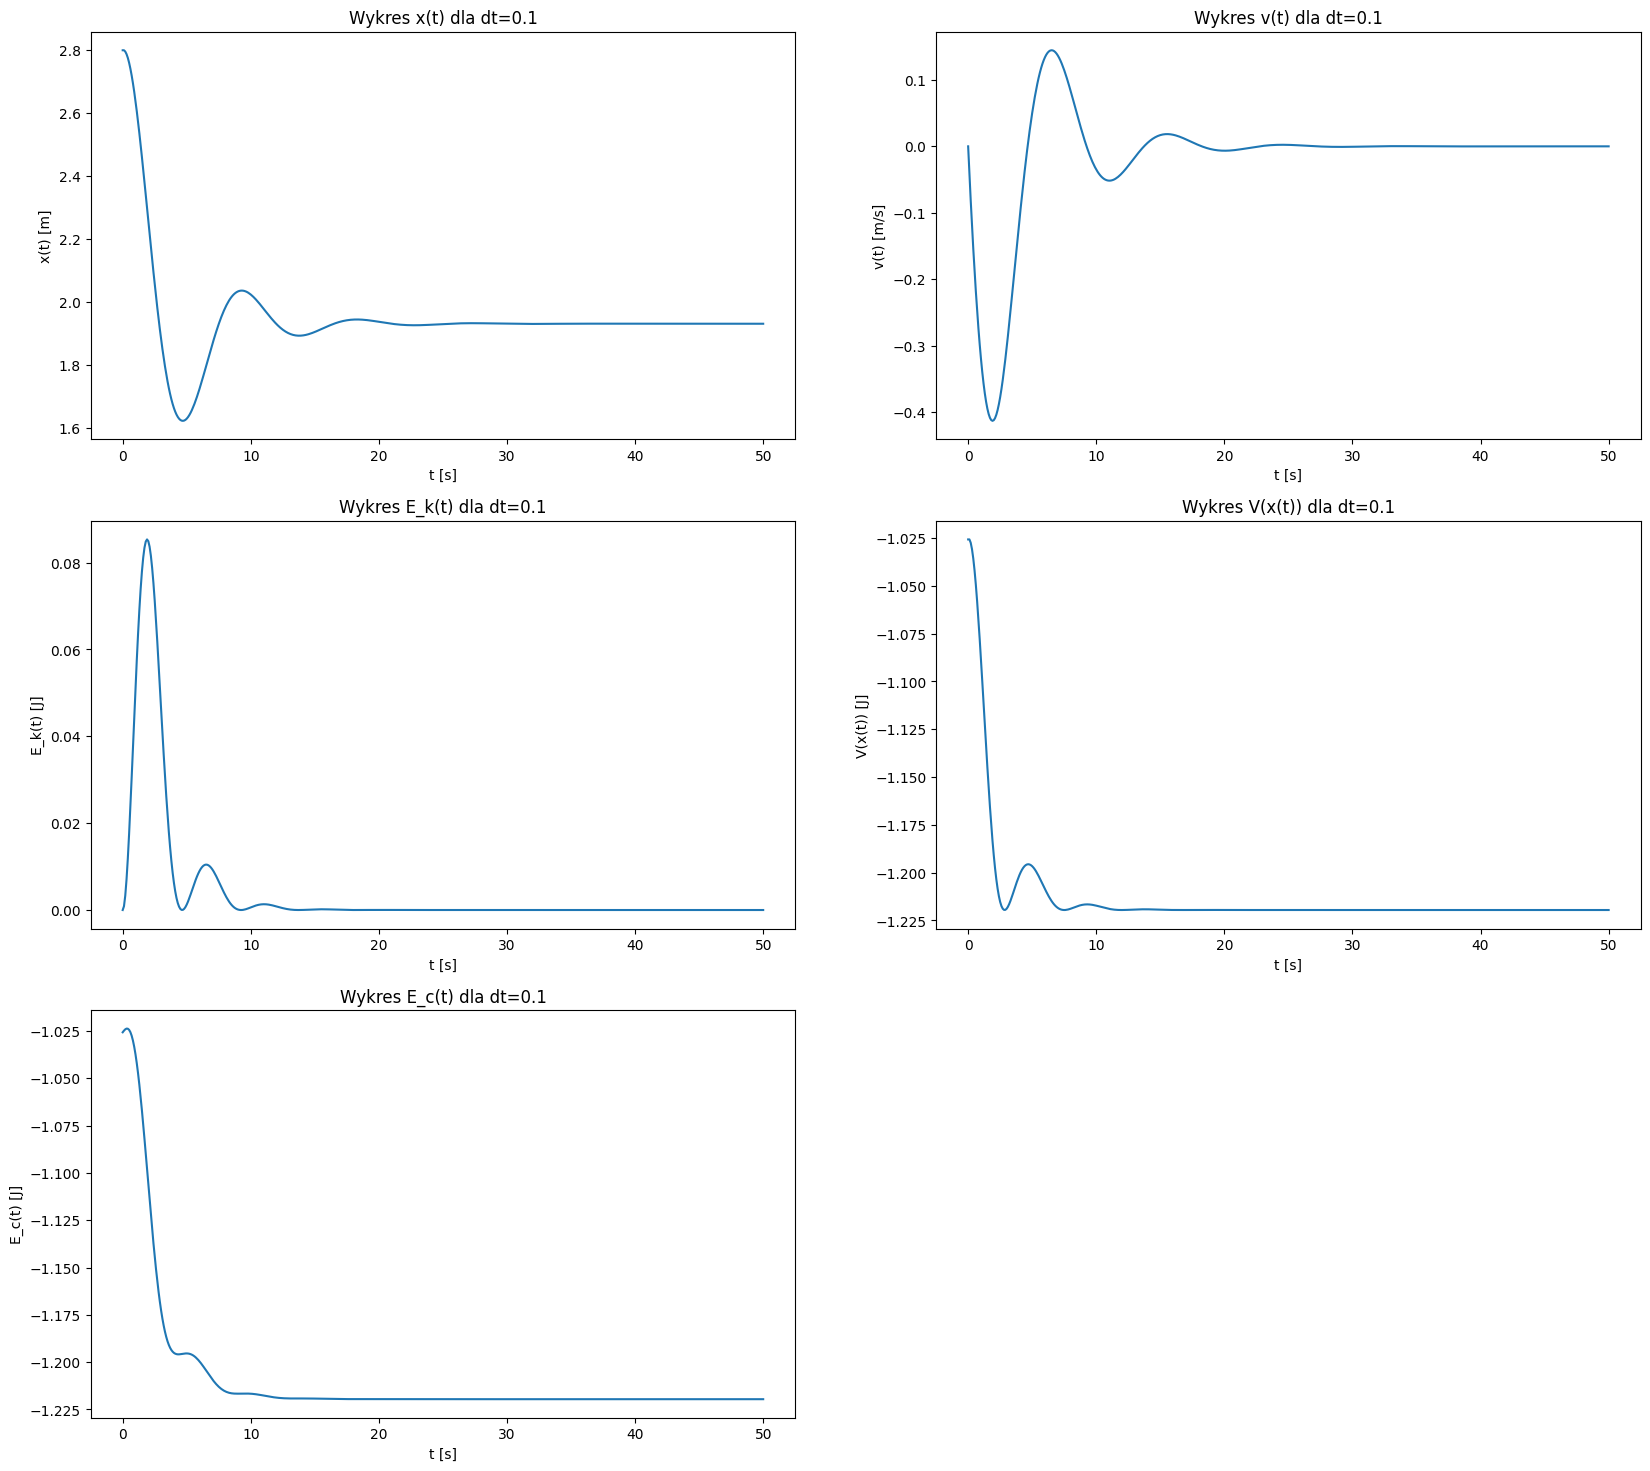

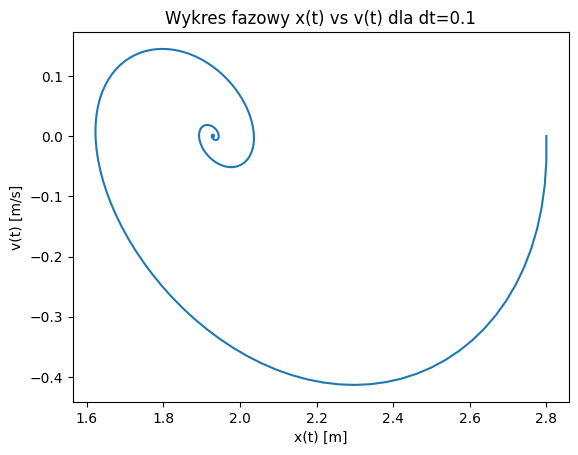

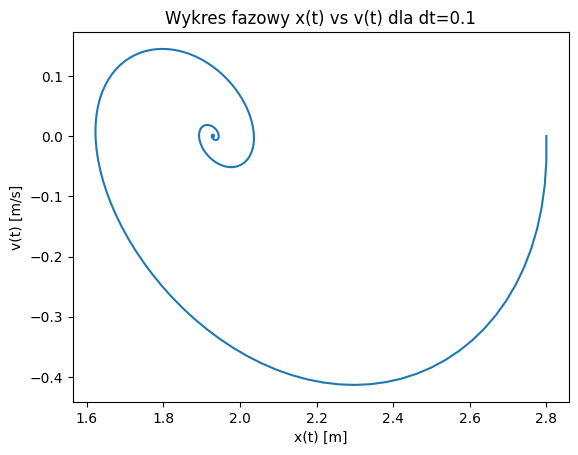

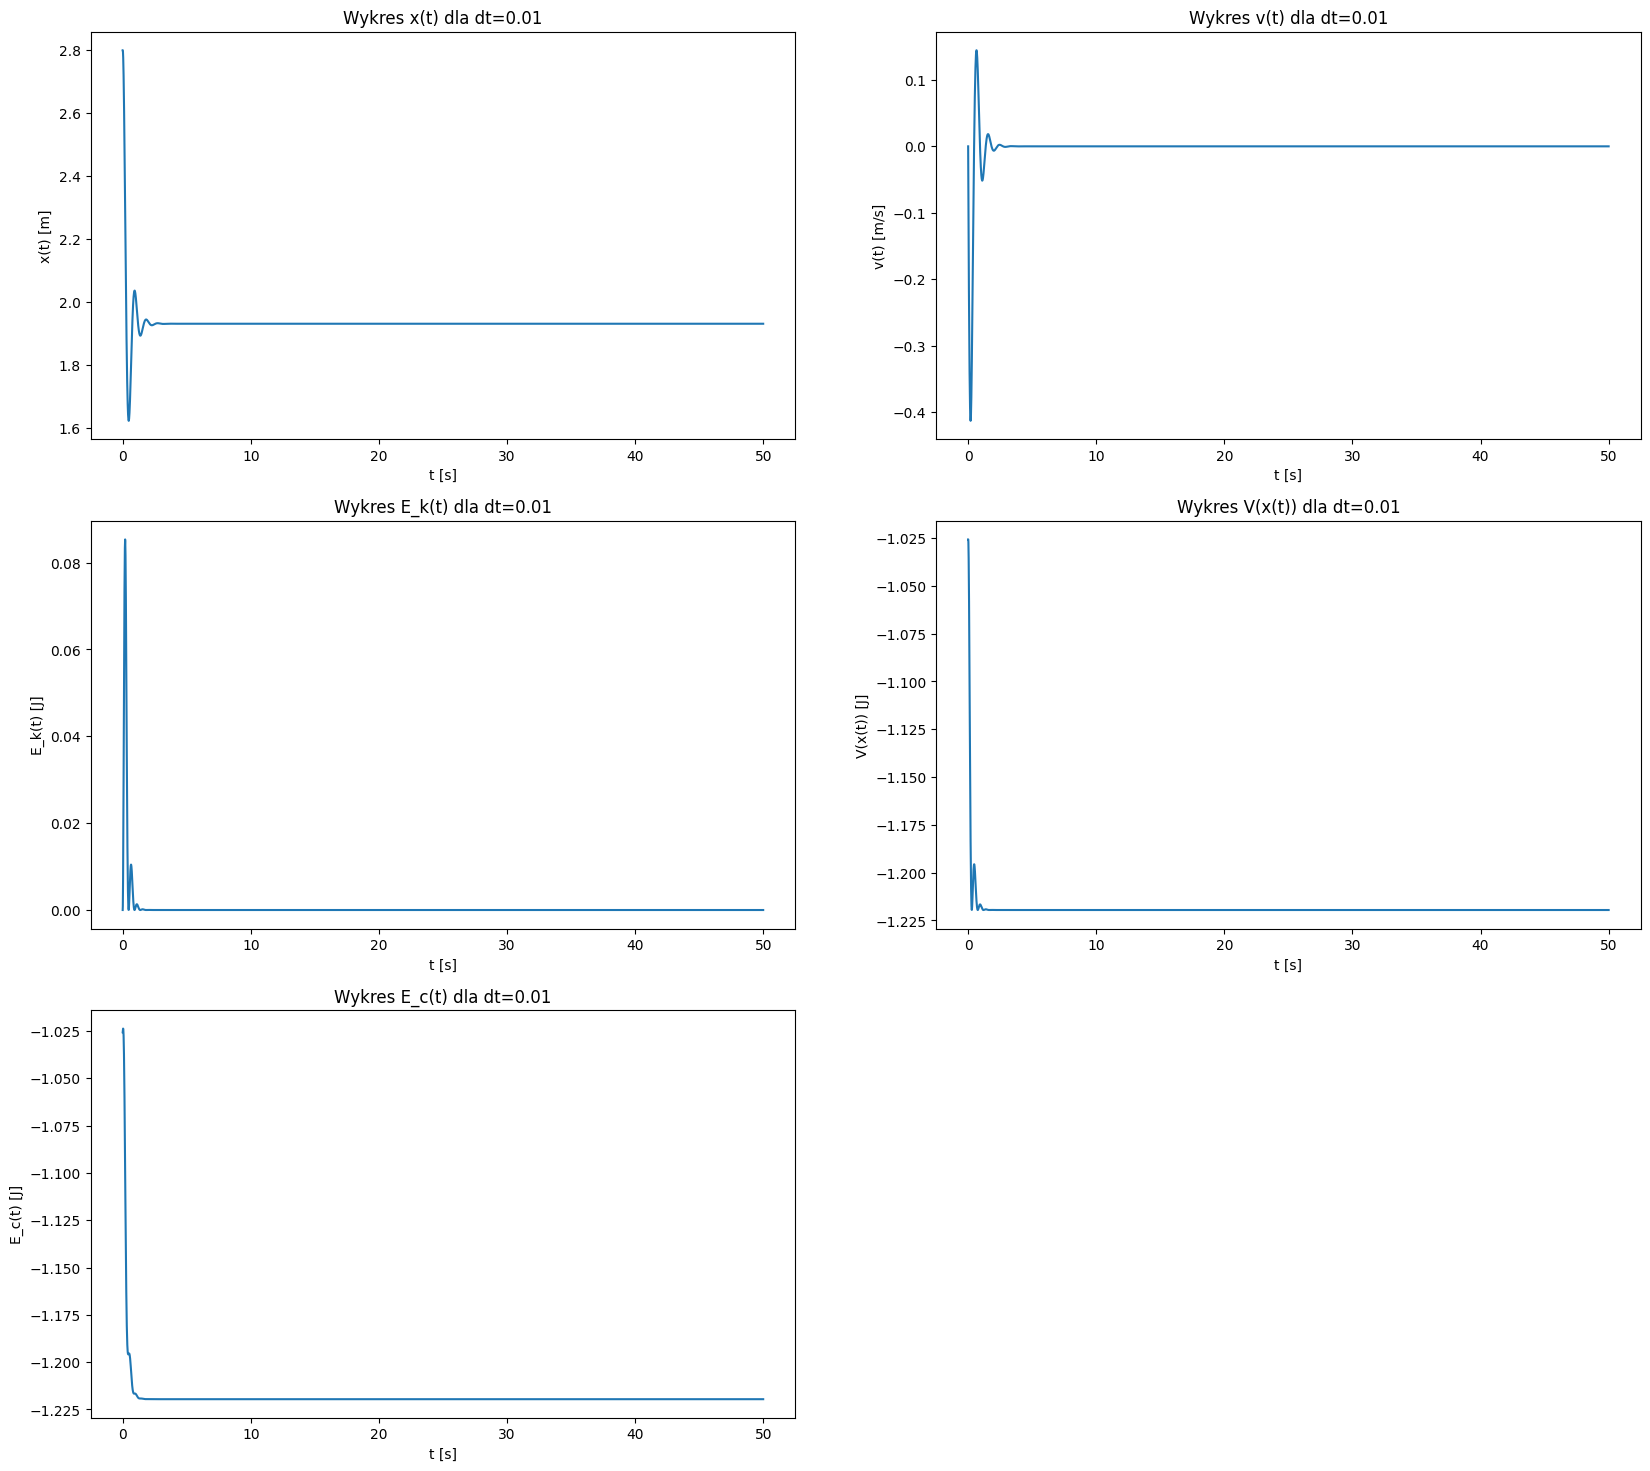

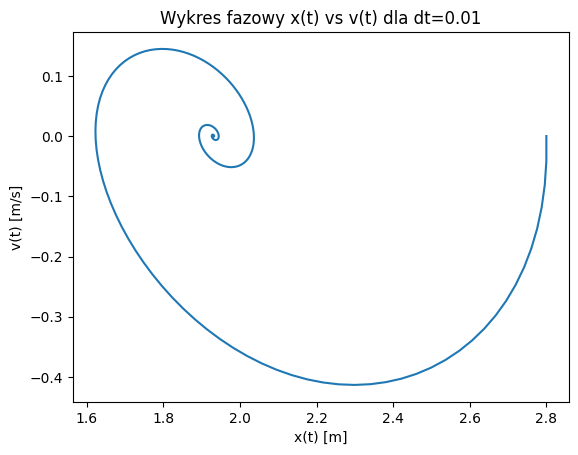

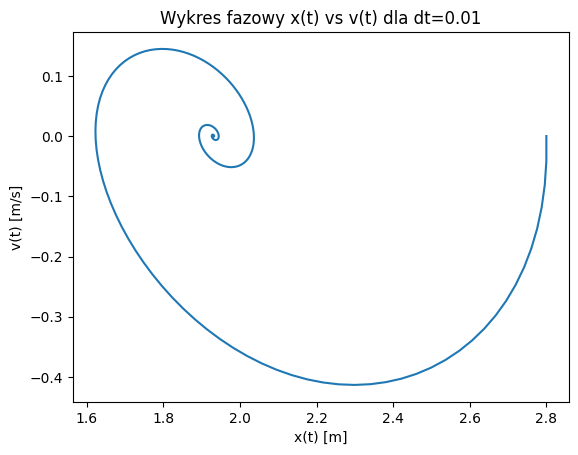

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import numba as nb
alfa=0.5
m=1
dt=[0.1,0.01]
t_0=0
x_0=2.8
v_0=0
tk_tab=[50,100,1000]
dx=0.001
@nb.njit
def V(x):
  return -np.exp(-((x+2)/2)**2)-1.2*np.exp(-((x-2)/2)**2)
@nb.njit
def dVdx(x):
    return (V(x+dx)-V(x-dx))/2/dx
@nb.njit
def energia(x, v):
    Ek=0.5*m*v**2
    Ep=V(x)
    return Ek,Ep,Ek+Ep
@nb.njit
def symuluj_ruch(t_k,dt,m,x0,v0,alfa):
    t=np.arange(0, t_k + dt, dt)
    kroki=len(t)
    x_tab=np.zeros(kroki)
    v_tab=np.zeros(kroki)
    x_tab[0],v_tab[0]=x0,v0
    Ek_tab=np.zeros(kroki)
    Ek_tab[0]=0
    Ep_tab=np.zeros(kroki)
    Ep_tab[0]=V(x_tab[0])
    E_c=np.zeros(kroki)
    E_c[0]=Ep_tab[0]+Ek_tab[0]
    for n in range(1, kroki):
        force=-dVdx(x_tab[n-1])
        x_tab[n]=x_tab[n-1]+v_tab[n-1]*krok_czasowy
        v_tab[n]=v_tab[n-1]+(force / m)*krok_czasowy-alfa*v_tab[n-1]*krok_czasowy
        Ek_tab[n],Ep_tab[n],E_c[n]=energia(x_tab[n],v_tab[n])
    return x_tab,v_tab,Ek_tab,Ep_tab,E_c,t
for krok_czasowy in dt:
  for t_k in tk_tab:
    x_tab,v_tab,Ek_tab,Ep_tab,E_c,t=symuluj_ruch(t_k,krok_czasowy,m,x_0,v_0,alfa)
    if t_k==50:
      plt.figure(figsize=(20,18))
      plt.subplot(3,2,1)
      plt.plot(t, x_tab)
      plt.title(f"Wykres x(t) dla dt={krok_czasowy}")
      plt.xlabel("t [s]")
      plt.ylabel("x(t) [m]")

      plt.subplot(3,2,2)
      plt.plot(t, v_tab)
      plt.title(f"Wykres v(t) dla dt={krok_czasowy}")
      plt.xlabel("t [s]")
      plt.ylabel("v(t) [m/s]")

      plt.subplot(3,2,3)
      plt.plot(t, Ek_tab)
      plt.title(f"Wykres E_k(t) dla dt={krok_czasowy}")
      plt.xlabel("t [s]")
      plt.ylabel("E_k(t) [J]")

      plt.subplot(3,2,4)
      plt.plot(t, Ep_tab)
      plt.title(f"Wykres V(x(t)) dla dt={krok_czasowy}")
      plt.xlabel("t [s]")
      plt.ylabel("V(x(t)) [J]")

      plt.subplot(3,2,5)
      plt.plot(t, E_c)
      plt.title(f"Wykres E_c(t) dla dt={krok_czasowy}")
      plt.xlabel("t [s]")
      plt.ylabel("E_c(t) [J]")
      plt.show()
    else:
      plt.plot(x_tab,v_tab)
      plt.title(f"Wykres fazowy x(t) vs v(t) dla dt={krok_czasowy}")
      plt.xlabel("x(t) [m]")
      plt.ylabel("v(t) [m/s]")
      plt.show()

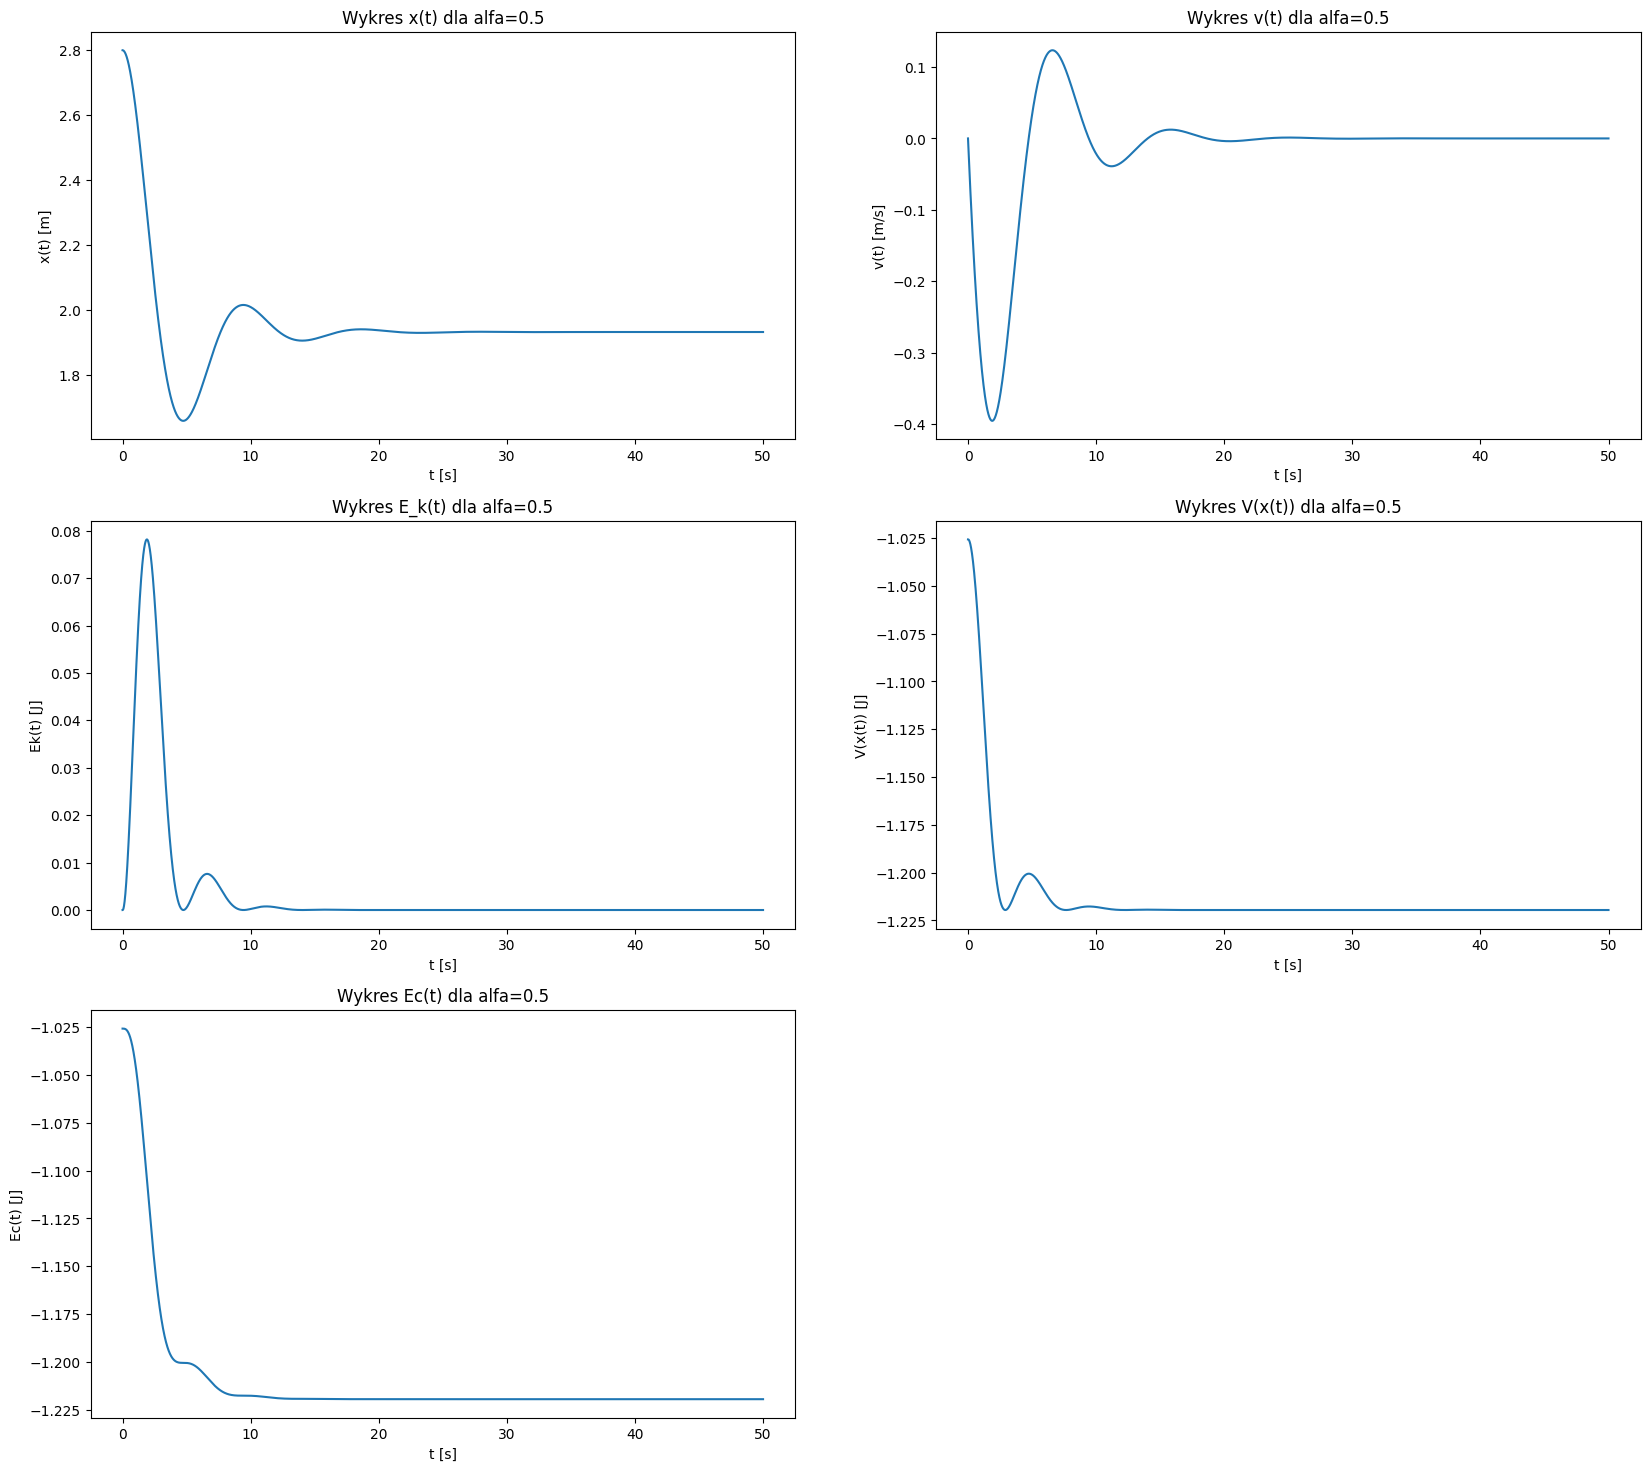

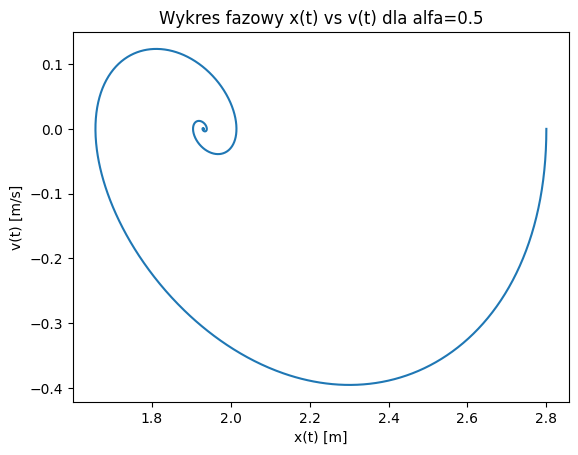

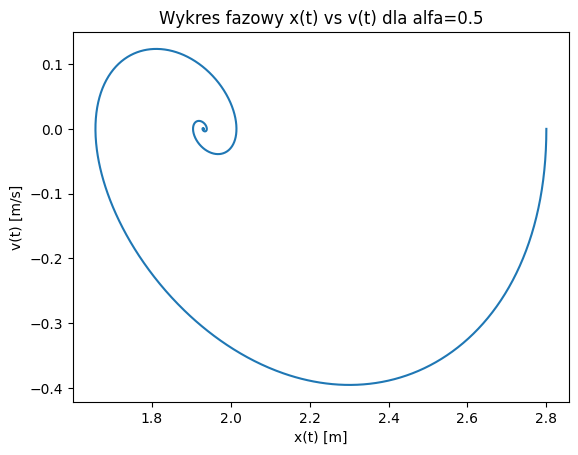

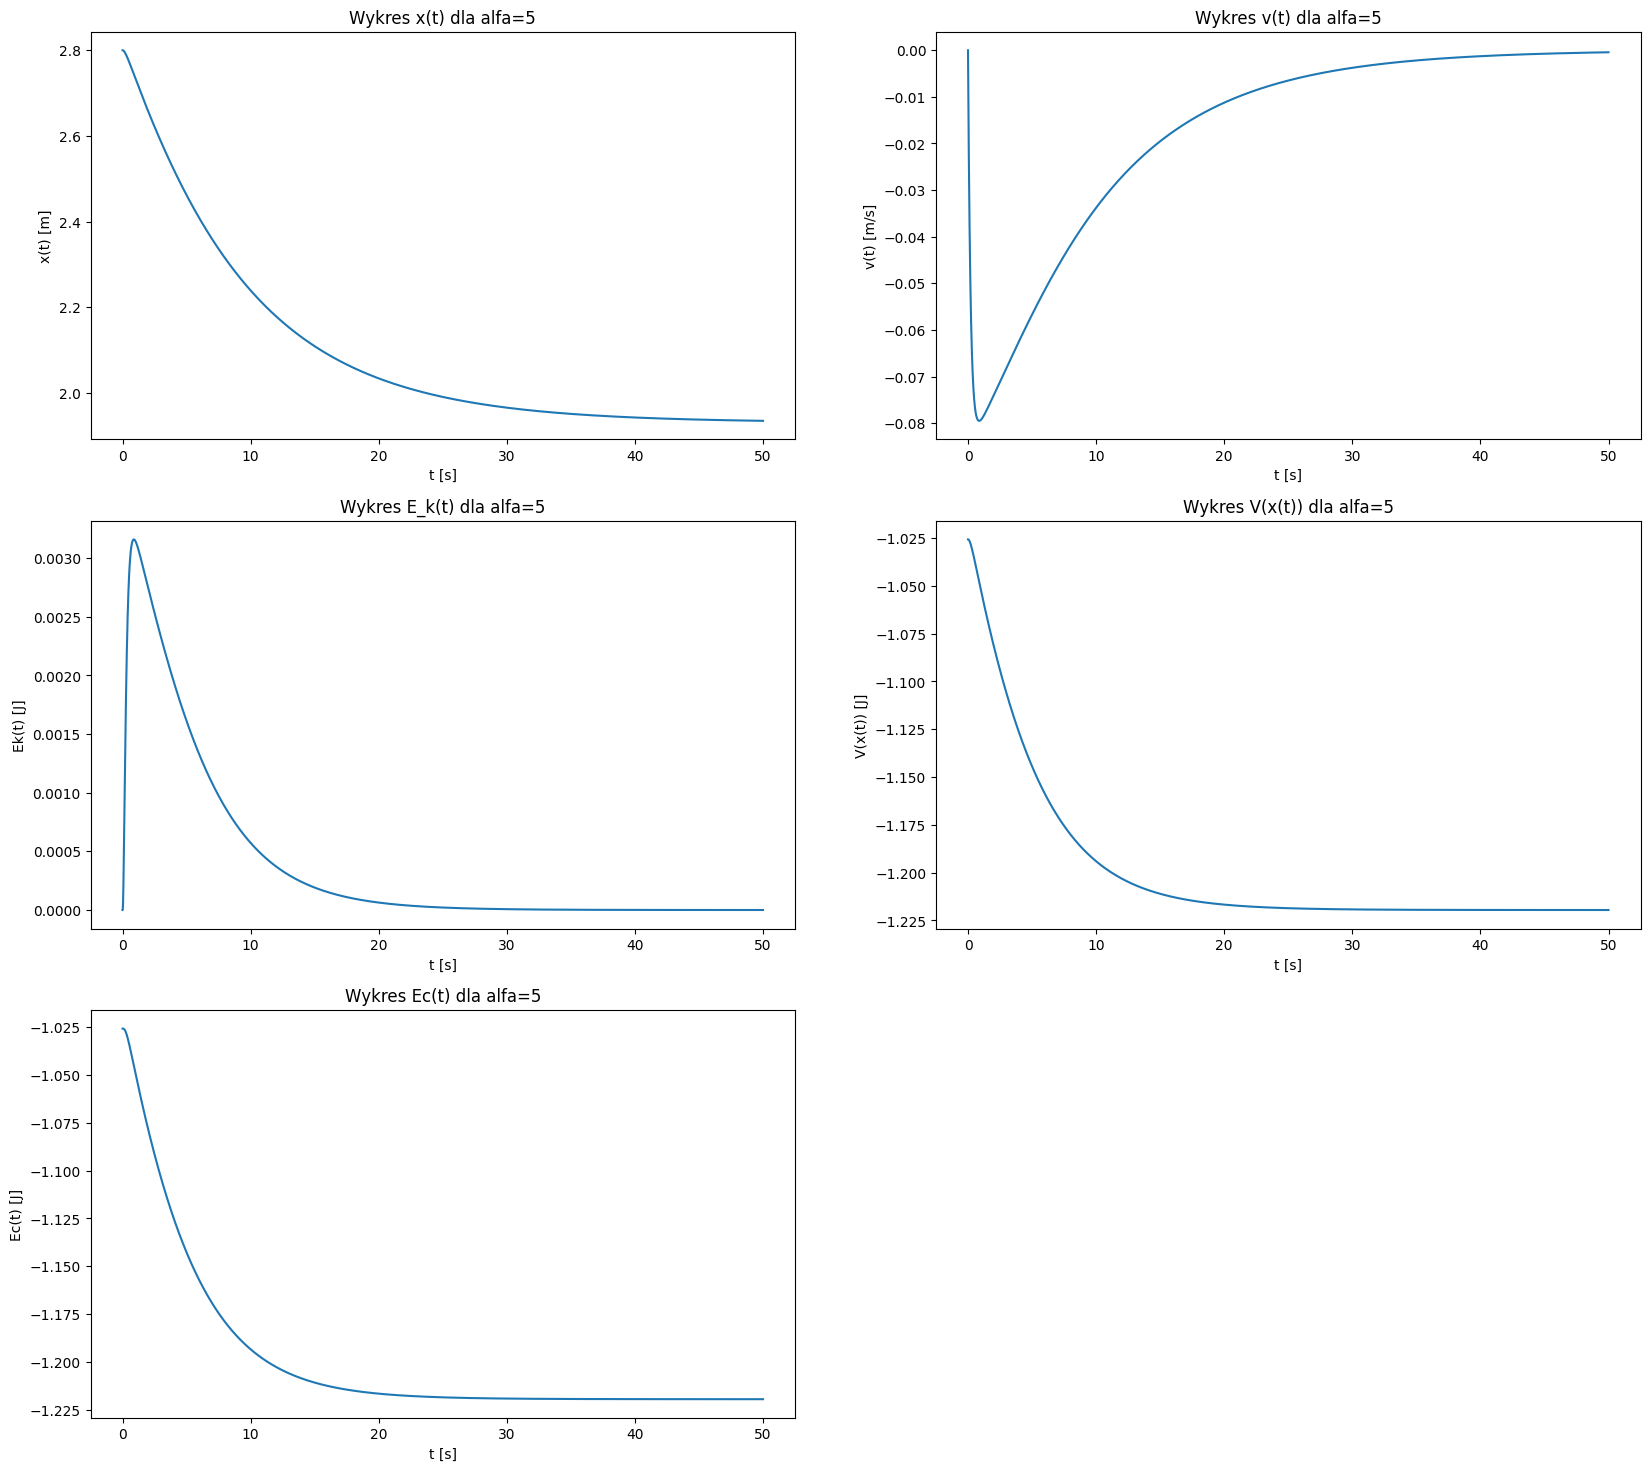

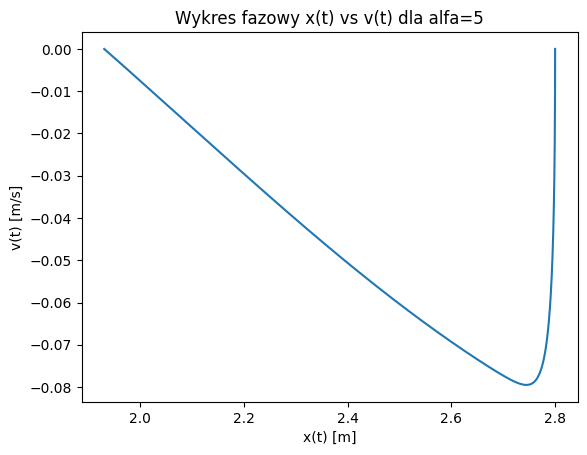

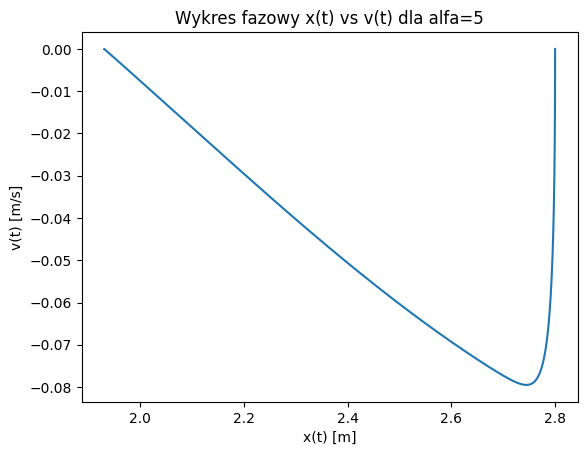

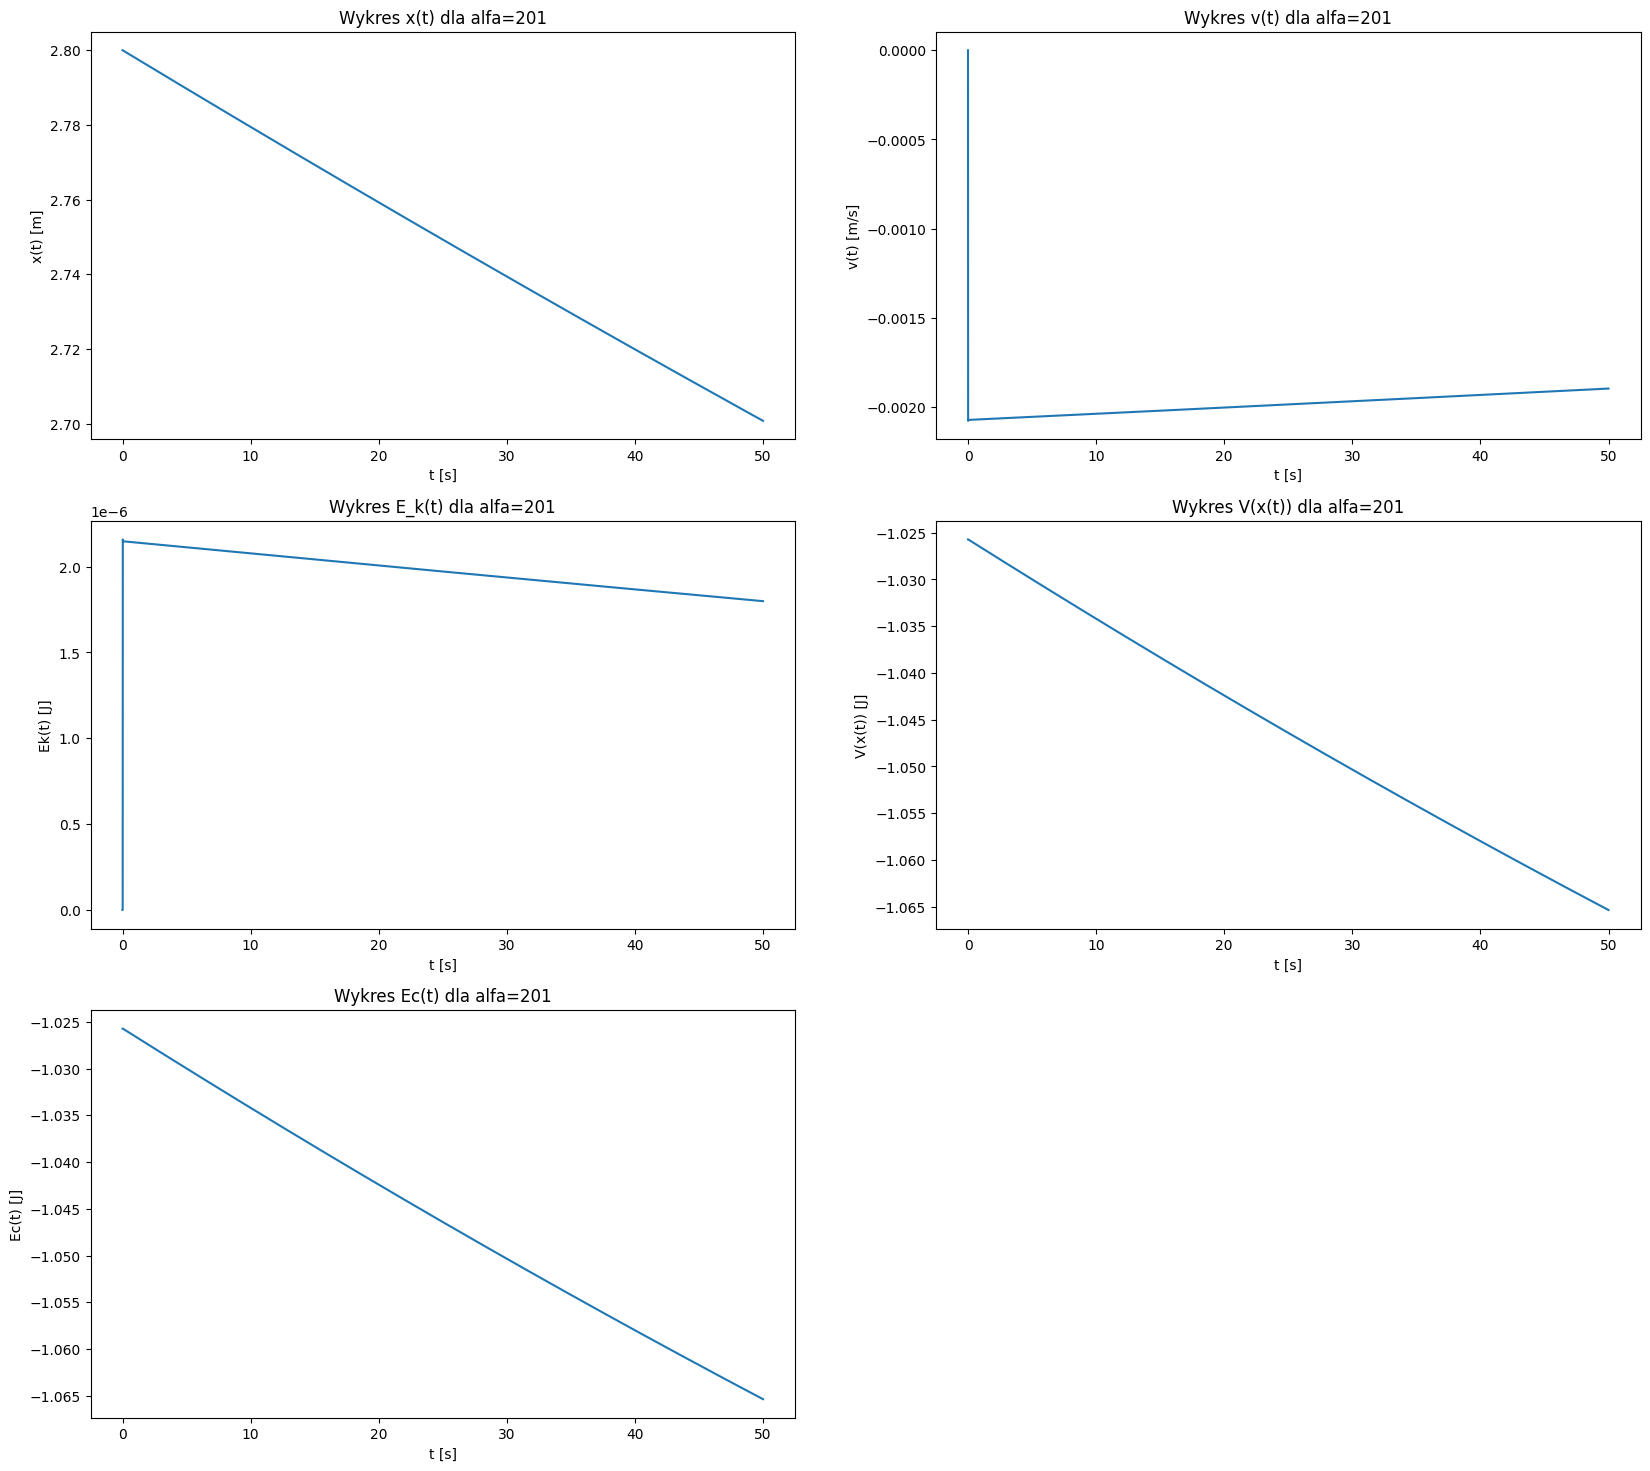

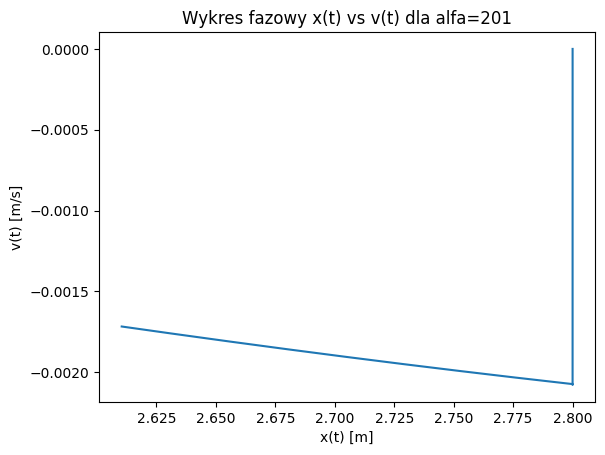

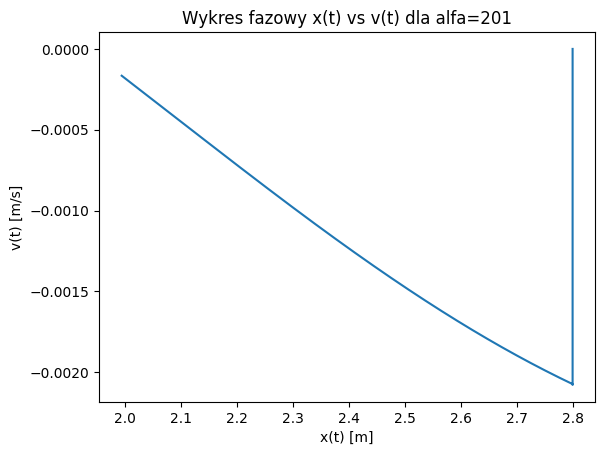

In [35]:
import numpy as np
import matplotlib.pyplot as plt
m=1
dx=0.001
dt=0.01
v0=0
x0=2.8
t_zakres=[50,100,1000]
alfa_zbior=[0.5,5,201]
@nb.njit
def V(x):
    return -np.exp(-((x+2)/2)**2)-1.2*np.exp(-((x-2)/2)**2)
@nb.njit
def dVdx(x):
    return (V(x+dx)-V(x-dx))/(2*dx)
@nb.njit
def d2Vdx2(x):
    return (V(x+dx)-2*V(x)+V(x-dx))/dx**2
@nb.njit
def metoda_trapezow(xn,vn,dt,alfa):
    x_nowe=xn
    v_nowe=vn
    for n in range(5):
      F1=x_nowe-xn-dt/2*(v_nowe+vn)
      F2=v_nowe-vn-dt/2*(-(1/m)*dVdx(x_nowe)-alfa*v_nowe-(1/m)*dVdx(xn)-alfa*vn)
      a11=1 #pierwszy element macierzy
      a12=-dt/2 #drugi element macierzy
      a21=dt/(2*m)*d2Vdx2(x_nowe) #trzeci element macierzy
      a22=1+dt/2*alfa #czwarty element macierzy
      A=np.array([[a11,a12],[a21,a22]])
      b=-np.array([F1,F2])
      delta=np.linalg.solve(A, b)
      x_nowe+=delta[0]
      v_nowe+=delta[1]
    return x_nowe,v_nowe
@nb.njit
def energia(x, v):
    Ek=0.5*m*v**2
    Ep=V(x)
    return Ek,Ep,Ek+Ep
@nb.njit
def symulacja(alfa,t_k,dt,v0,x0):
    t=np.arange(0,t_k+dt,dt)
    kroki=len(t)
    x=np.zeros(kroki)
    v=np.zeros(kroki)
    x[0],v[0]=x0,v0
    Ek=np.zeros(kroki)
    Ek[0]=0
    Ep=np.zeros(kroki)
    Ep[0]=V(x_tab[0])
    Ec=np.zeros(kroki)
    Ec[0]=Ep[0]+Ek[0]
    for n in range(kroki):
      if n!=kroki:
        x[n+1],v[n+1]=metoda_trapezow(x[n],v[n],dt,alfa)
      Ek[n+1],Ep[n+1],Ec[n+1]=energia(x[n],v[n])
    return x,v,Ek,Ep,Ec,t
for alfa in alfa_zbior:
  for t_k in t_zakres:
    x,v,Ek,Ep,Ec,t=symulacja(alfa,t_k,dt,v0,x0)
    if t_k==50:
      plt.figure(figsize=(20,18))
      plt.subplot(3,2,1)
      plt.plot(t,x)
      plt.title(f"Wykres x(t) dla alfa={alfa}")
      plt.xlabel("t [s]")
      plt.ylabel("x(t) [m]")

      plt.subplot(3,2,2)
      plt.plot(t,v)
      plt.title(f"Wykres v(t) dla alfa={alfa}")
      plt.xlabel("t [s]")
      plt.ylabel("v(t) [m/s]")

      plt.subplot(3,2,3)
      plt.plot(t,Ek)
      plt.title(f"Wykres E_k(t) dla alfa={alfa}")
      plt.xlabel("t [s]")
      plt.ylabel("Ek(t) [J]")

      plt.subplot(3,2,4)
      plt.plot(t,Ep)
      plt.title(f"Wykres V(x(t)) dla alfa={alfa}")
      plt.xlabel("t [s]")
      plt.ylabel("V(x(t)) [J]")

      plt.subplot(3,2,5)
      plt.plot(t,Ec)
      plt.title(f"Wykres Ec(t) dla alfa={alfa}")
      plt.xlabel("t [s]")
      plt.ylabel("Ec(t) [J]")
      plt.show()
    else:
      plt.plot(x,v)
      plt.title(f"Wykres fazowy x(t) vs v(t) dla alfa={alfa}")
      plt.xlabel("x(t) [m]")
      plt.ylabel("v(t) [m/s]")
      plt.show()

In [32]:
import numpy as np
m=1
dx=0.001
dt=0.01
alfa=0
def V(x):
    return -np.exp(-((x+2)/2)**2)-1.2*np.exp(-((x-2)/2)**2)
def dVdx(x):
    return (V(x+dx)-V(x-dx))/(2*dx)
def d2Vdx2(x):
    return (V(x+dx)-2*V(x)+V(x-dx))/dx**2
x0=2.8
v0=0
x_nowe=x0
v_nowe=v0
for n in range(20):
  F1=x_nowe-x0-dt/2*(v_nowe+v0)
  F2=v_nowe-v0-dt/2*(-(1/m)*dVdx(x_nowe)-alfa*v_nowe-(1/m)*dVdx(x0)-alfa*v0)
  a11=1 #pierwszy element macierzy
  a12=-dt/2 #drugi element macierzy
  a21=dt/(2*m)*d2Vdx2(x_nowe) #trzeci element macierzy
  a22=1+dt/2*alfa #czwarty element macierzy
  A=np.array([[a11,a12],[a21,a22]])
  b=-np.array([F1,F2])
  delta=np.linalg.solve(A, b)
  x_nowe+=delta[0]
  v_nowe+=delta[1]
  print(f"Iteracja {n+1}: F1={abs(F1):.3e}, F2={abs(F2):.3e}")
  if abs(F1)<1e-15 and abs(F2)<1e-15:
      print(f"Osiągnięto zadowalającą dokładność w iteracji {n+1}")
      break

Iteracja 1: F1=0.000e+00, F2=4.166e-03
Iteracja 2: F1=1.755e-16, F2=5.569e-13
Iteracja 3: F1=5.553e-17, F2=4.337e-18
Osiągnięto zadowalającą dokładność w iteracji 3


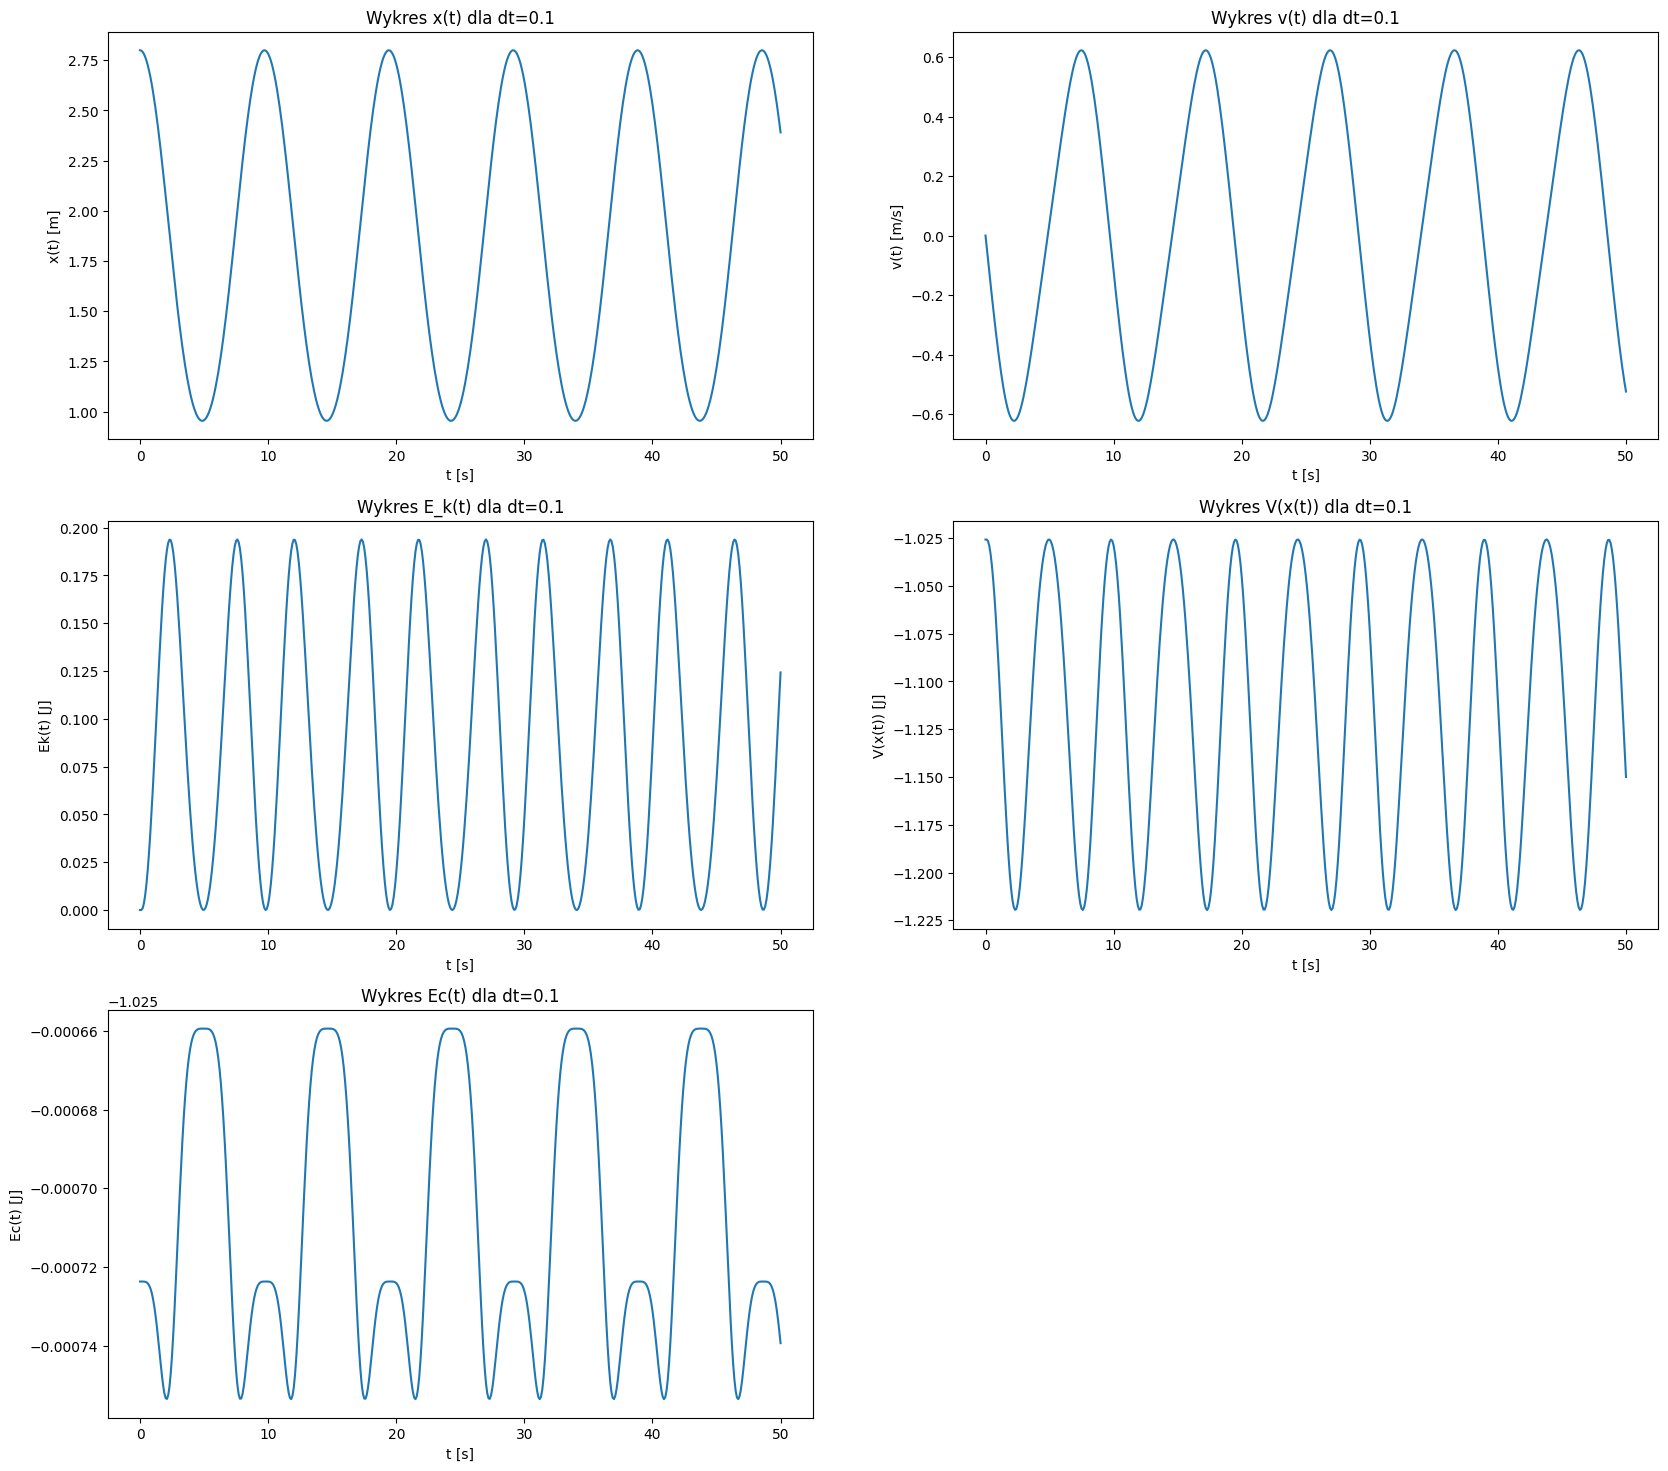

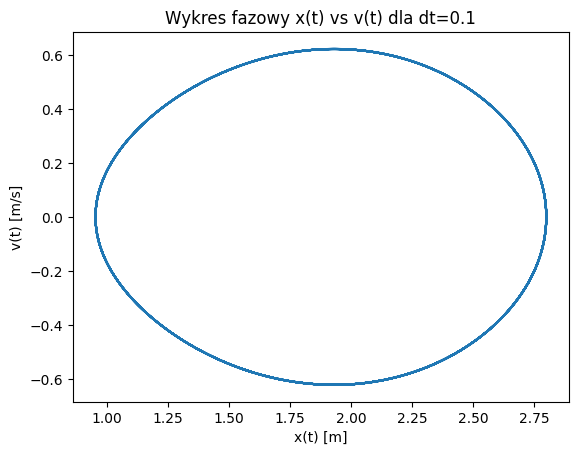

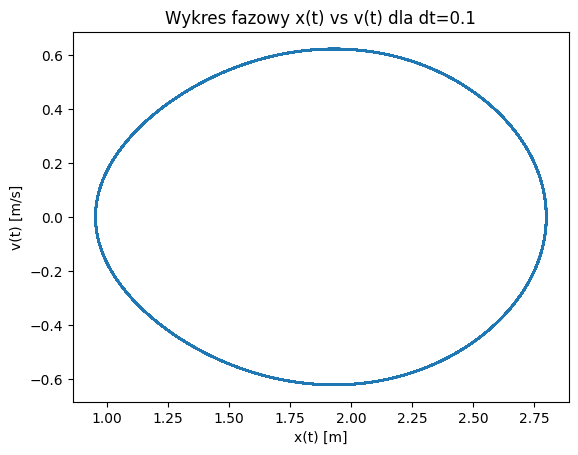

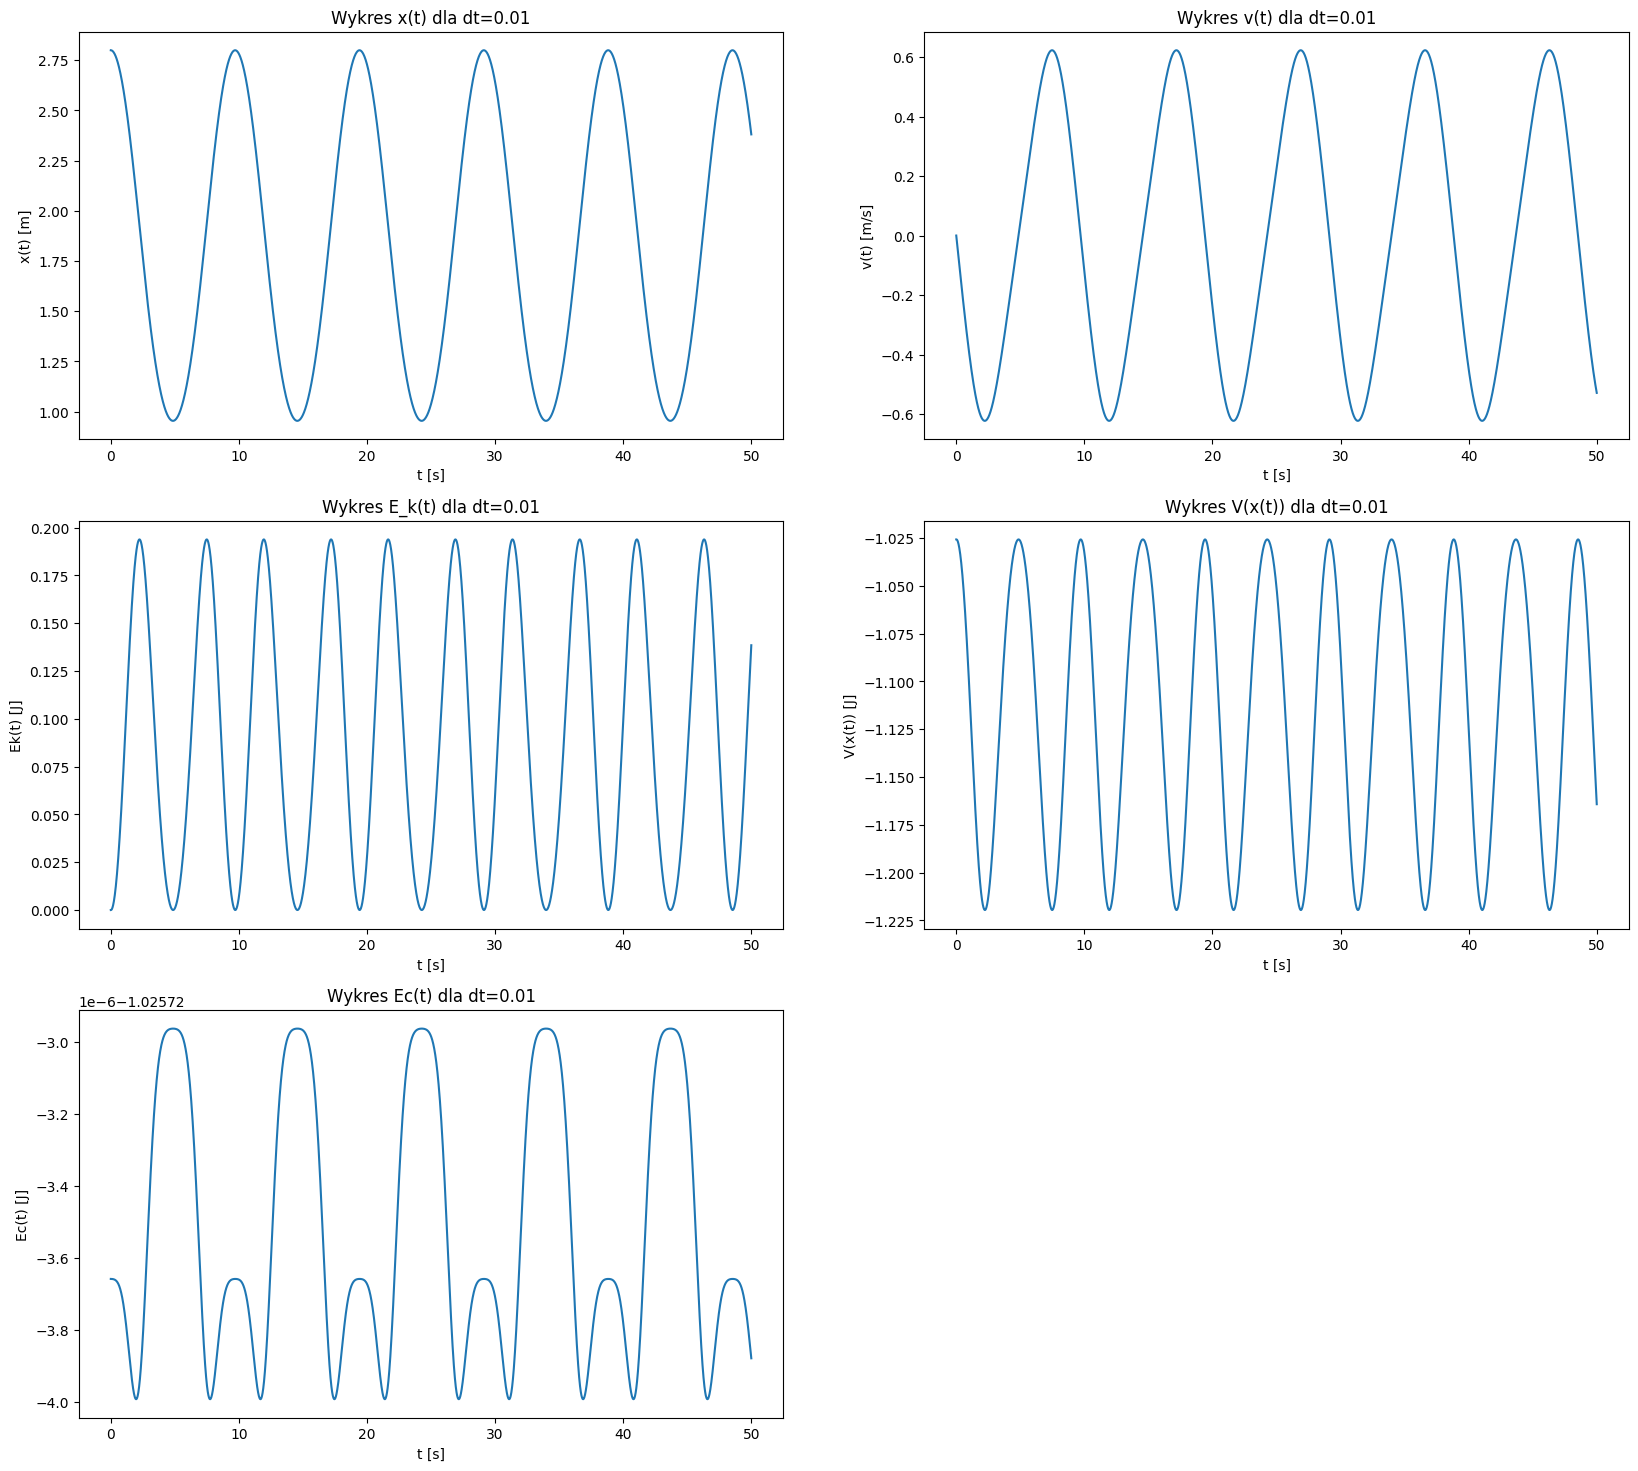

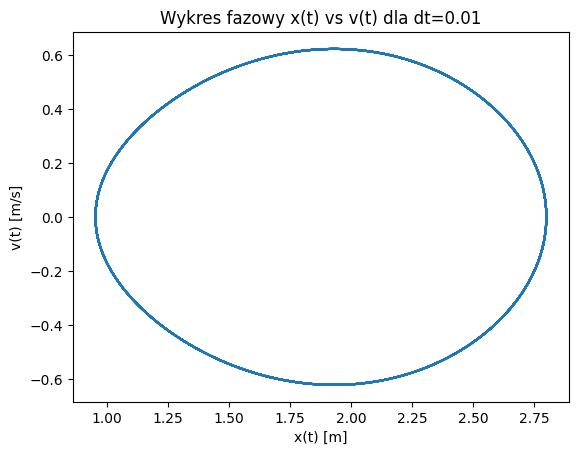

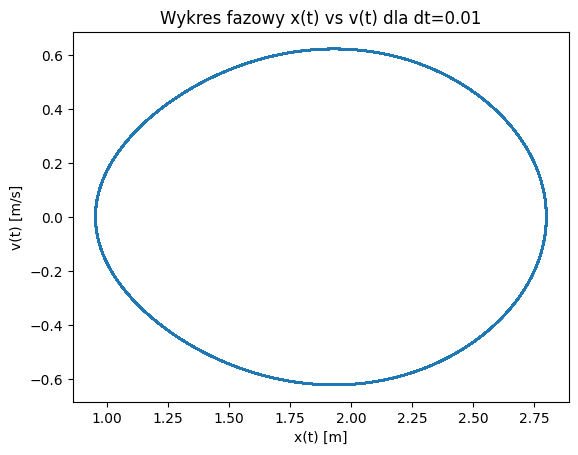

In [37]:
import numpy as np
import matplotlib.pyplot as plt
m=1
dx=0.001
dt_zakres=[0.1,0.01]
v0=0
x0=2.8
t_zakres=[50,100,1000]
alfa=0
@nb.njit
def V(x):
    return -np.exp(-((x+2)/2)**2)-1.2*np.exp(-((x-2)/2)**2)
@nb.njit
def dVdx(x):
    return (V(x+dx)-V(x-dx))/(2*dx)
@nb.njit
def d2Vdx2(x):
    return (V(x+dx)-2*V(x)+V(x-dx))/dx**2
@nb.njit
def metoda_trapezow(xn,vn,dt,alfa):
    x_nowe=xn
    v_nowe=vn
    for n in range(5):
      F1=x_nowe-xn-dt/2*(v_nowe+vn)
      F2=v_nowe-vn-dt/2*(-(1/m)*dVdx(x_nowe)-alfa*v_nowe-(1/m)*dVdx(xn)-alfa*vn)
      a11=1 #pierwszy element macierzy
      a12=-dt/2 #drugi element macierzy
      a21=dt/(2*m)*d2Vdx2(x_nowe) #trzeci element macierzy
      a22=1+dt/2*alfa #czwarty element macierzy
      A=np.array([[a11,a12],[a21,a22]])
      b=-np.array([F1,F2])
      delta=np.linalg.solve(A, b)
      x_nowe+=delta[0]
      v_nowe+=delta[1]
    return x_nowe,v_nowe
@nb.njit
def energia(x, v):
    Ek=0.5*m*v**2
    Ep=V(x)
    return Ek,Ep,Ek+Ep
@nb.njit
def symulacja(alfa,t_k,dt,v0,x0):
    t=np.arange(0,t_k+dt,dt)
    kroki=len(t)
    x=np.zeros(kroki)
    v=np.zeros(kroki)
    x[0],v[0]=x0,v0
    Ek=np.zeros(kroki)
    Ek[0]=0
    Ep=np.zeros(kroki)
    Ep[0]=V(x_tab[0])
    Ec=np.zeros(kroki)
    Ec[0]=Ep[0]+Ek[0]
    for n in range(kroki):
      if n!=kroki:
        x[n+1],v[n+1]=metoda_trapezow(x[n],v[n],dt,alfa)
      Ek[n+1],Ep[n+1],Ec[n+1]=energia(x[n],v[n])
    return x,v,Ek,Ep,Ec,t
for dt in dt_zakres:
  for t_k in t_zakres:
    x,v,Ek,Ep,Ec,t=symulacja(alfa,t_k,dt,v0,x0)
    if t_k==50:
      plt.figure(figsize=(20,18))
      plt.subplot(3,2,1)
      plt.plot(t,x)
      plt.title(f"Wykres x(t) dla dt={dt}")
      plt.xlabel("t [s]")
      plt.ylabel("x(t) [m]")

      plt.subplot(3,2,2)
      plt.plot(t,v)
      plt.title(f"Wykres v(t) dla dt={dt}")
      plt.xlabel("t [s]")
      plt.ylabel("v(t) [m/s]")

      plt.subplot(3,2,3)
      plt.plot(t,Ek)
      plt.title(f"Wykres E_k(t) dla dt={dt}")
      plt.xlabel("t [s]")
      plt.ylabel("Ek(t) [J]")

      plt.subplot(3,2,4)
      plt.plot(t,Ep)
      plt.title(f"Wykres V(x(t)) dla dt={dt}")
      plt.xlabel("t [s]")
      plt.ylabel("V(x(t)) [J]")

      plt.subplot(3,2,5)
      plt.plot(t,Ec)
      plt.title(f"Wykres Ec(t) dla dt={dt}")
      plt.xlabel("t [s]")
      plt.ylabel("Ec(t) [J]")
      plt.show()
    else:
      plt.plot(x,v)
      plt.title(f"Wykres fazowy x(t) vs v(t) dla dt={dt}")
      plt.xlabel("x(t) [m]")
      plt.ylabel("v(t) [m/s]")
      plt.show()